# Fundamentals 1 · Data and a Pretrained Network

Before building networks from scratch, this notebook looks at both ends of the pipeline: tabular data
loaded with pandas, and a large pretrained image classifier (VGG16, 138 million parameters) used as a
black box. The rest of the project opens that box.

## Exploring a dataset with pandas

`data/wine_quality_red.csv` holds the chemical properties of 1,599 red wines together with a human taste
rating from 1 to 10. The cell below finds one of the highest-rated wines and lists its chemical
properties — the kind of features a network could later use to predict quality without a human taster.

In [4]:
from pathlib import Path

# the repository root is the first folder above this notebook that holds pyproject.toml
REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
DATA_DIR = REPO_ROOT / "data"

import pandas as pd

df = pd.read_csv(DATA_DIR / 'wine_quality_red.csv', sep=';')
# df.head() - top 5 data rows

# max_quality = df.quality.max()
loc_of_max = int(df.quality.idxmax())
# print(f"Max quality: {max_quality}, Index {loc_of_max}")

info = df.iloc[loc_of_max]
print(info[:len(info)-1])

fixed acidity            7.9000
volatile acidity         0.3500
citric acid              0.4600
residual sugar           3.6000
chlorides                0.0780
free sulfur dioxide     15.0000
total sulfur dioxide    37.0000
density                  0.9973
pH                       3.3500
sulphates                0.8600
alcohol                 12.8000
Name: 267, dtype: float64


## Classifying photos with a pretrained VGG16

VGG16, trained on ImageNet, labels ten animal photos. The photos (`data/images/`) are not included in the
repository, so the outputs below come from the original run.

**Step 1:** Import libraries.

In [5]:
import torch
from torchvision import models, transforms
from PIL import Image
import os
import pandas as pd
import matplotlib.pyplot as plt

**Step 2:** Load the pretrained VGG16 model and set it to evaluation mode.

In [6]:
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

**Step 3:** Define the image transformations the model expects (resize, crop, normalize).

In [7]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]),
])

**Step 4:** Load the ImageNet class labels, to turn the model's numeric output into a readable word.

In [8]:
import json
import requests
url = "https://raw.githubusercontent.com/anishathalye/" \
"imagenet-simple-labels/master/imagenet-simple-labels.json"
response = requests.get(url)
response.raise_for_status()
labels = response.json()

**Step 5:** Run every image in the folder through the model and record the results.

In [9]:
image_folder = DATA_DIR / 'images'
results = []
for image_file in os.listdir(image_folder):
    image_path = os.path.join(image_folder, image_file)
    true_label = os.path.splitext(image_file)[0]

    img = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(img)
    input_batch = input_tensor.unsqueeze(0) # type: ignore

    with torch.no_grad():
        output = model(input_batch)
    
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_prob, top_cat_id = torch.max(probabilities, 0)
    predicted_label = labels[top_cat_id]

    results.append({
        'Filename': image_file,
        'True Label': true_label,
        'Predicted Label': predicted_label,
        'Confidence': top_prob.item()
    })

**Step 6:** Collect the results in a DataFrame.

In [10]:
df = pd.DataFrame(results)
display(df)

,Filename,True Label,Predicted Label,Confidence
0,bird.png,bird,bee eater,0.607000
1,camel.png,camel,dromedary,0.999992
2,cat.png,cat,tiger cat,0.215769
3,dog.png,dog,Labrador Retriever,0.950855
4,fox.png,fox,red fox,0.500303
5,giraffe.png,giraffe,cheetah,0.415470
6,lion.png,lion,lion,1.000000
7,squirrel.png,squirrel,fox squirrel,0.996254
8,tiger.png,tiger,tiger,0.706100
9,zebra.png,zebra,zebra,0.999990


**Step 7:** Show each image with its true label, predicted label and confidence.

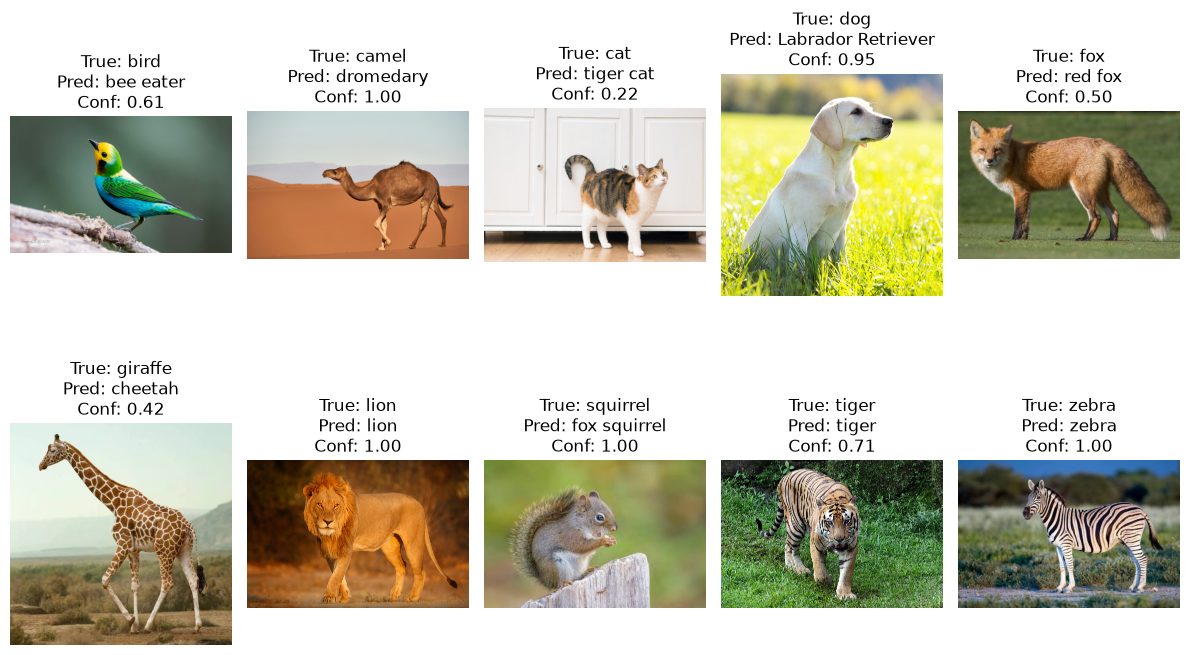

In [11]:
plt.figure(figsize=(12, 8))
for i, row in df.iterrows():
    image_path = os.path.join(image_folder, row['Filename'])
    img = Image.open(image_path)
    plt.subplot(2, 5, i + 1) # type: ignore
    plt.imshow(img)
    plt.title(f"True: {row['True Label']}\nPred: {row['Predicted Label']}"
              f"\nConf: {row['Confidence']:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Takeaway

VGG16 predicts ImageNet's fine-grained classes, so most "wrong-looking" labels are really more specific
answers: a *dromedary* is a camel, a *fox squirrel* a squirrel, a *Labrador Retriever* a dog, a *bee eater*
a bird. The one real mistake is the giraffe, labelled *cheetah* with 42% confidence — perhaps because of
its spotted coat. Confidence also varies widely, from 100% for the lion to 22% for the cat. All of this
comes from 138 million weights nobody set by hand; how such weights are learned is what the following
notebooks build up to.